# **Практическая работа №10. Сравнение моделей классификации изображений и развертывание API**


## **Цель работы**


Провести сравнительный анализ ранее обученных моделей классификации изображений (работы 2-5), выбрать лучшую по метрикам качества, развернуть ее в виде API и создать пользовательский интерфейс с помощью Streamlit.

---

### **Раздел 1. Подготовка и анализ моделей**


1. Загрузить выбранный датасет для классификации изображений
2. Загрузить ранее обученные модели (из практических работ 2-5)
3. Сравнить модели по метрикам качества:
   - Точность (accuracy)
   - Полнота (recall)
   - Precision
   - F1-мера
   - Время инференса (Время, затрачиваемое моделью на формирование предсказания. Измеряется путём усреднения результатов на нескольких тысячах изображений)
4. Создать сводный DataFrame с результатами всех моделей
5. Визуализировать результаты сравнения с помощью графиков
6. Построить матрицы ошибок для каждой модели
7. Выбрать лучшую модель по F1-мере
8. Сохранить лучшую модель

Mounted at /content/drive
TF: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Классы: ['Asian Green Bee-Eater', 'Brown-Headed Barbet', 'Common Kingfisher']

Проверка файлов моделей:
  OK Dense (ПР-2)
  OK CNN (ПР-3)
  OK CNN+BN+Dropout (ПР-4)
  OK EfficientNetB4 (ПР-5)

Загрузка изображений 128×128...


  Test: (555, 128, 128, 3)

Загрузка изображений 224×224...


  Test: (555, 224, 224, 3)


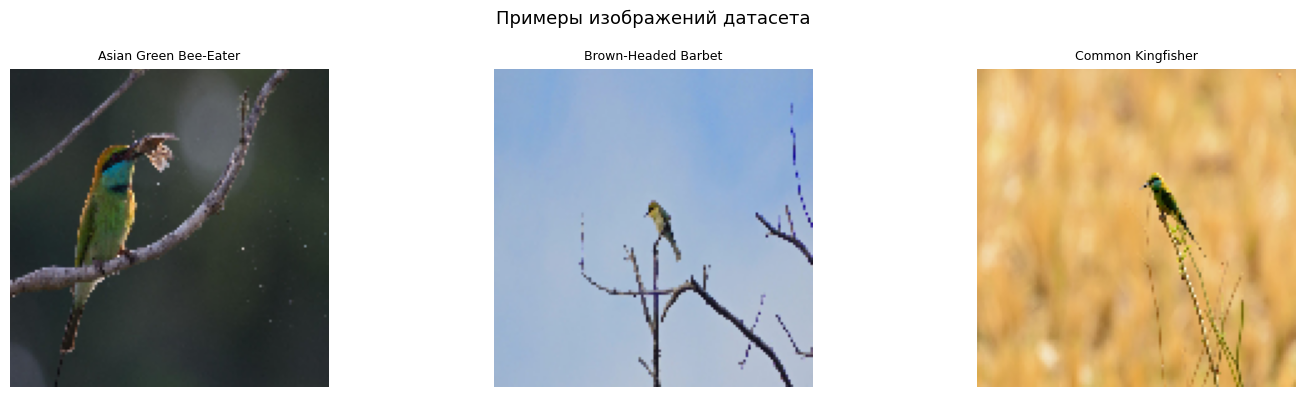


Загрузка моделей...
  ✅ Dense (ПР-2)
  ✅ CNN (ПР-3)
  ✅ CNN+BN+Dropout (ПР-4)
  ✅ EfficientNetB4 (ПР-5)

Вычисление метрик...
  Dense (ПР-2): Acc=0.5640 | P=0.5851 | R=0.5640 | F1=0.5507 | 1.184 ms/img
  CNN (ПР-3): Acc=0.8883 | P=0.8905 | R=0.8883 | F1=0.8878 | 1.768 ms/img
  CNN+BN+Dropout (ПР-4): Acc=0.9315 | P=0.9315 | R=0.9315 | F1=0.9314 | 2.374 ms/img
  EfficientNetB4 (ПР-5): Acc=0.5423 | P=0.5792 | R=0.5423 | F1=0.4776 | 30.403 ms/img

=== Сводная таблица метрик ===


,Модель,Accuracy,Precision,Recall,F1,Inference (ms/img)
1,CNN+BN+Dropout (ПР-4),0.9315,0.9315,0.9315,0.9314,2.374
2,CNN (ПР-3),0.8883,0.8905,0.8883,0.8878,1.768
3,Dense (ПР-2),0.5640,0.5851,0.5640,0.5507,1.184
4,EfficientNetB4 (ПР-5),0.5423,0.5792,0.5423,0.4776,30.403


/tmp/ipykernel_3191/139659515.py:183: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(model_names, rotation=15, ha='right')


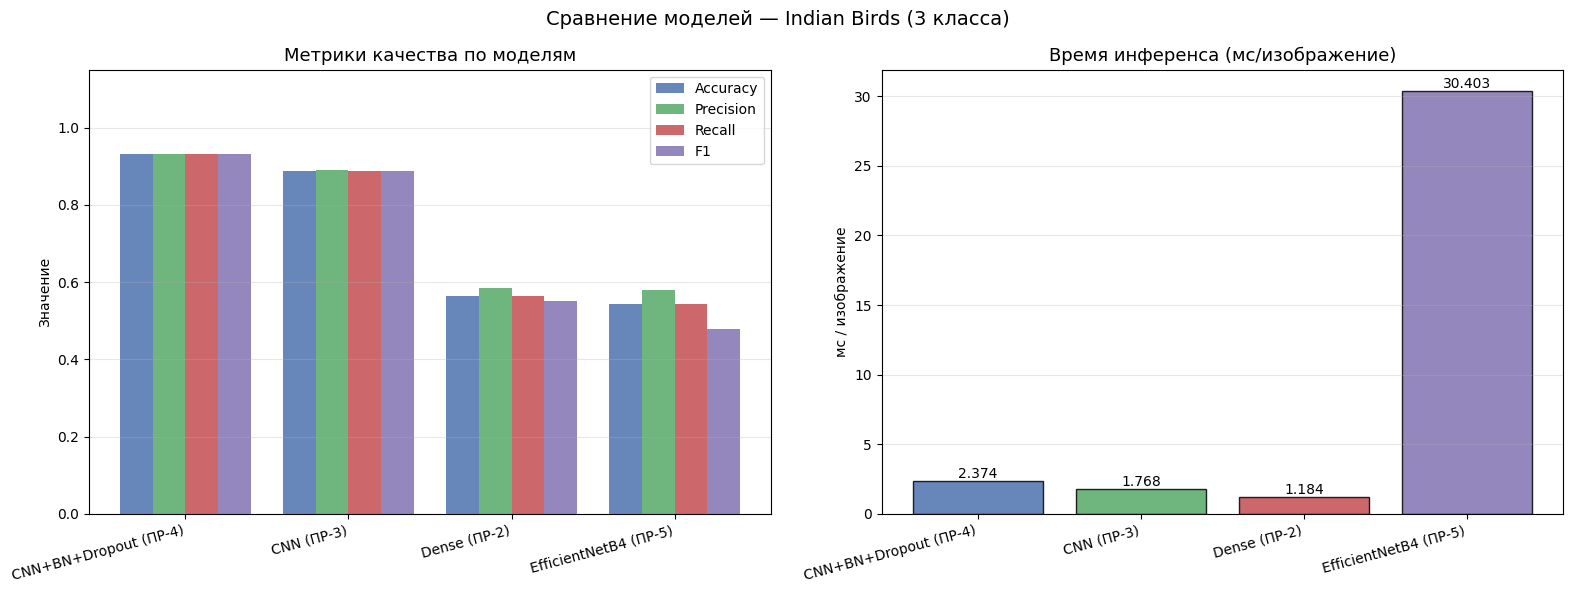

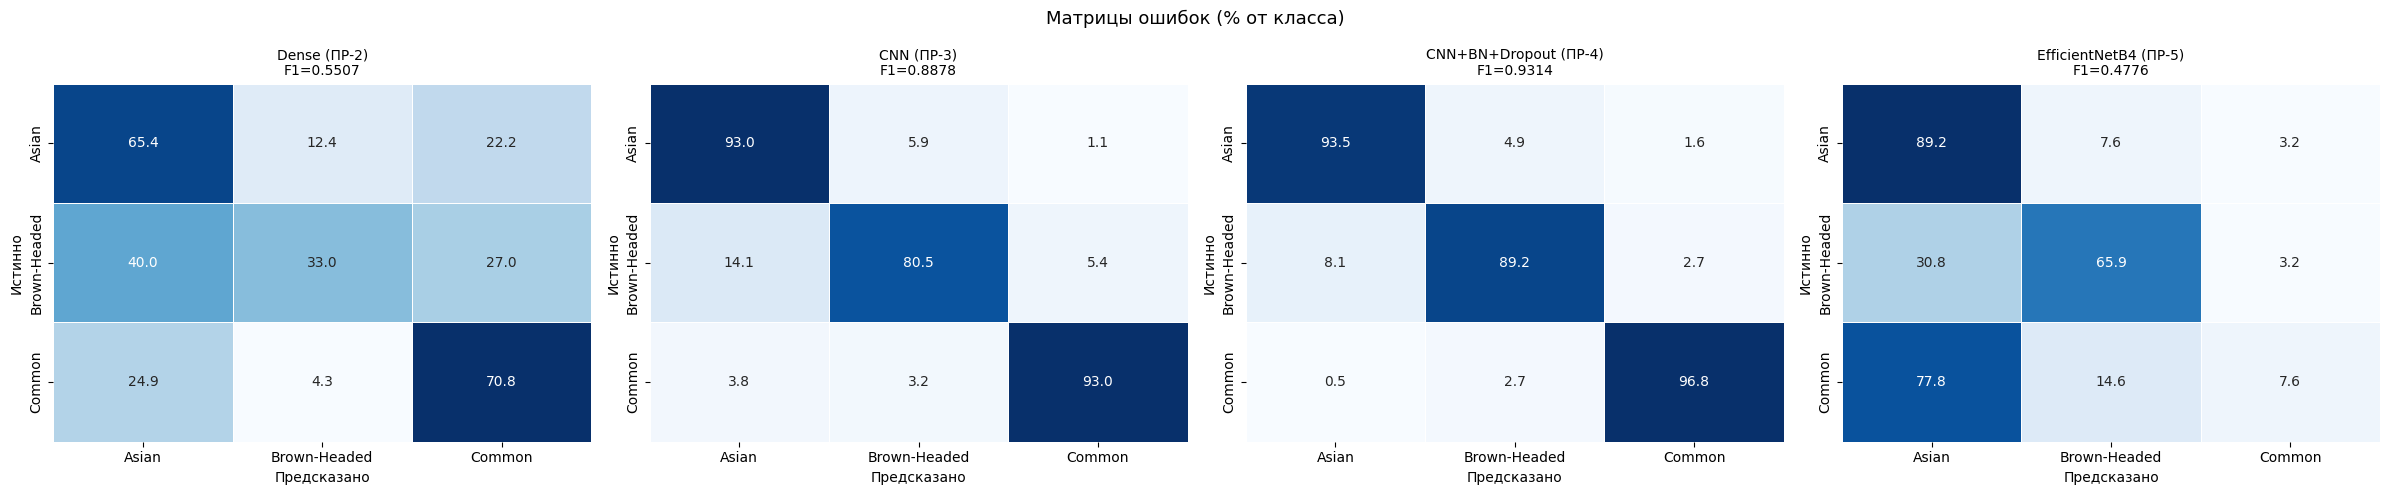


 Лучшая модель по F1: CNN+BN+Dropout (ПР-4)  (F1 = 0.9314)


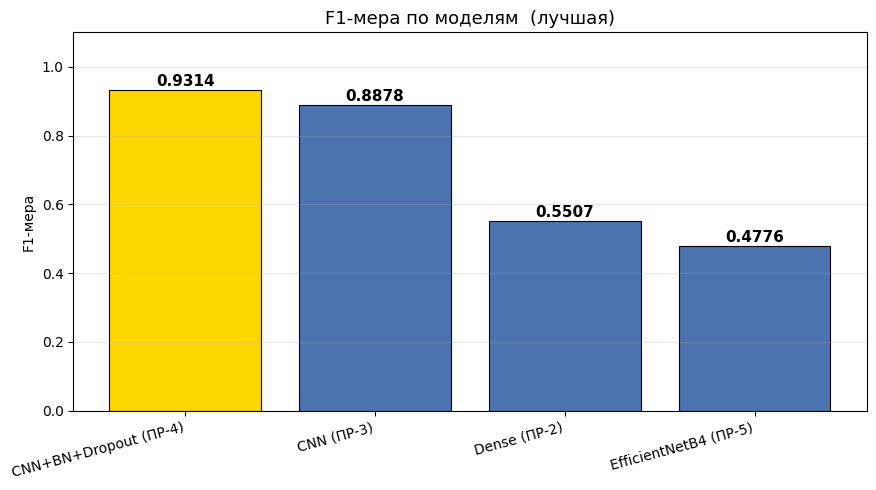

Лучшая модель сохранена: /content/drive/MyDrive/ПР-10/best_classification_model.keras
Метаданные:              /content/drive/MyDrive/ПР-10/model_meta.json
Таблица результатов:     /content/drive/MyDrive/ПР-10/comparison_results.csv


In [ ]:
  # Ваш код

# Зависимости и импорты
import os, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tqdm import tqdm
from google.colab import drive

import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)

drive.mount('/content/drive')
print('TF:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

# 1. Пути и конфигурация
DATASET_PATH = '/content/drive/MyDrive/ПР-3/Dataset'
MODELS_DIR   = '/content/drive/MyDrive/ПР-10/models'
SAVE_DIR     = '/content/drive/MyDrive/ПР-10'
SEED         = 42

# Конфигурация моделей: имя → файл + размер входного изображения
MODEL_CONFIGS = {
    'Dense (ПР-2)': {
        'file':     'model_pr2_dense.keras',
        'img_size': 128,
    },
    'CNN (ПР-3)': {
        'file':     'model_pr3_cnn.keras',
        'img_size': 128,
    },
    'CNN+BN+Dropout (ПР-4)': {
        'file':     'model_pr4_cnn_bn_dropout.keras',
        'img_size': 128,
    },
    'EfficientNetB4 (ПР-5)': {
        'file':     'model_pr5_efficientnet.keras',
        'img_size': 224,
    },
}

CLASS_NAMES = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])
print('Классы:', CLASS_NAMES)

# Проверка наличия файлов
print('\nПроверка файлов моделей:')
for name, cfg in MODEL_CONFIGS.items():
    path = os.path.join(MODELS_DIR, cfg['file'])
    print(f'  {"OK" if os.path.exists(path) else "Error"} {name}')

# 2. Загрузка датасета
def load_images(path, img_size, classes):
    X, y = [], []
    for cls in classes:
        cls_path = os.path.join(path, cls)
        for fname in tqdm(os.listdir(cls_path), desc=cls, leave=False):
            img = cv2.imread(os.path.join(cls_path, fname))
            if img is None:
                continue
            img = cv2.resize(img, (img_size, img_size))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            X.append(img); y.append(cls)
    return np.array(X, dtype='float32') / 255.0, np.array(y)

# Загружаем для каждого уникального размера отдельно
datasets = {}
for img_size in sorted({cfg['img_size'] for cfg in MODEL_CONFIGS.values()}):
    print(f'\nЗагрузка изображений {img_size}×{img_size}...')
    X, y_str = load_images(DATASET_PATH, img_size, CLASS_NAMES)
    lb = LabelBinarizer()
    y_ohe = lb.fit_transform(y_str)
    _, X_test, _, y_test, _, y_str_test = train_test_split(
        X, y_ohe, y_str,
        test_size=0.2, random_state=SEED, stratify=y_str
    )
    datasets[img_size] = {
        'X_test': X_test, 'y_test': y_test, 'y_str_test': y_str_test
    }
    print(f'  Test: {X_test.shape}')

# Пример изображений по классам
fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(15, 4))
X_vis, y_vis = load_images(DATASET_PATH, 128, CLASS_NAMES)
for i, cls in enumerate(CLASS_NAMES):
    idx = np.where(y_vis == cls)[0][0] if hasattr(y_vis[0], '__len__') else \
          np.where(np.array([y_vis]) == cls)[1][0]
    axes[i].imshow(X_vis[i])
    axes[i].set_title(cls, fontsize=9); axes[i].axis('off')
plt.suptitle('Примеры изображений датасета', fontsize=13)
plt.tight_layout(); plt.show()

# 3. Загрузка обученных моделей
print('\nЗагрузка моделей...')
loaded_models = {}
for name, cfg in MODEL_CONFIGS.items():
    path = os.path.join(MODELS_DIR, cfg['file'])
    if os.path.exists(path):
        loaded_models[name] = keras.models.load_model(path)
        print(f'  ✅ {name}')
    else:
        print(f'  ❌ {name} — файл не найден')

# 4. Вычисление метрик
def compute_metrics(model, X_test, y_test_ohe):
    times = []
    for _ in range(3):
        t0 = time.time()
        preds = model.predict(X_test, verbose=0)
        times.append(time.time() - t0)
    ms_per_img = np.mean(times) / len(X_test) * 1000
    y_pred = np.argmax(preds, axis=1)
    y_true = np.argmax(y_test_ohe, axis=1)
    return {
        'Accuracy':           round(accuracy_score(y_true, y_pred), 4),
        'Precision':          round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'Recall':             round(recall_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'F1':                 round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'Inference (ms/img)': round(ms_per_img, 3),
        'y_pred': y_pred, 'y_true': y_true,
    }

print('\nВычисление метрик...')
results = {}
for name, model in loaded_models.items():
    ds = datasets[MODEL_CONFIGS[name]['img_size']]
    results[name] = compute_metrics(model, ds['X_test'], ds['y_test'])
    m = results[name]
    print(f'  {name}: Acc={m["Accuracy"]:.4f} | P={m["Precision"]:.4f} | '
          f'R={m["Recall"]:.4f} | F1={m["F1"]:.4f} | {m["Inference (ms/img)"]:.3f} ms/img')

# 5. Сводный DataFrame
metric_keys = ['Accuracy', 'Precision', 'Recall', 'F1', 'Inference (ms/img)']
df = pd.DataFrame(
    {name: {k: res[k] for k in metric_keys} for name, res in results.items()}
).T.reset_index().rename(columns={'index': 'Модель'})
df = df.sort_values('F1', ascending=False).reset_index(drop=True)
df.index += 1

print('\n=== Сводная таблица метрик ===')
display(df.style
    .highlight_max(subset=['Accuracy','Precision','Recall','F1'], color='#90EE90')
    .highlight_min(subset=['Inference (ms/img)'], color='#90EE90')
    .format({c: '{:.4f}' for c in ['Accuracy','Precision','Recall','F1']} |
            {'Inference (ms/img)': '{:.3f}'})
)

# 6. Визуализация результатов
model_names = df['Модель'].tolist()
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2'][:len(model_names)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x, width = np.arange(len(model_names)), 0.2

for i, metric in enumerate(['Accuracy', 'Precision', 'Recall', 'F1']):
    axes[0].bar(x + i*width, df[metric].astype(float), width,
                label=metric, color=colors[i], alpha=0.85)
axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(model_names, rotation=15, ha='right')
axes[0].set_ylim(0, 1.15)
axes[0].set_title('Метрики качества по моделям', fontsize=13)
axes[0].set_ylabel('Значение'); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

inf_times = df['Inference (ms/img)'].astype(float).tolist()
bars = axes[1].bar(model_names, inf_times, color=colors, alpha=0.85, edgecolor='black')
for bar, val in zip(bars, inf_times):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10)
axes[1].set_title('Время инференса (мс/изображение)', fontsize=13)
axes[1].set_ylabel('мс / изображение')
axes[1].set_xticklabels(model_names, rotation=15, ha='right')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Сравнение моделей — Indian Birds (3 класса)', fontsize=14)
plt.tight_layout(); plt.show()

# История обучения (если есть — пропустить, модели уже загружены)
# Матрицы ошибок отображаем ниже

# 7. Матрицы ошибок
n = len(results)
fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
if n == 1: axes = [axes]
short = [c.split()[0] for c in CLASS_NAMES]

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(res['y_true'], res['y_pred'])
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=short, yticklabels=short,
                ax=ax, cbar=False, linewidths=0.5)
    ax.set_title(f'{name}\nF1={res["F1"]:.4f}', fontsize=10)
    ax.set_xlabel('Предсказано'); ax.set_ylabel('Истинно')

plt.suptitle('Матрицы ошибок (% от класса)', fontsize=13)
plt.tight_layout(); plt.show()

# 8. Выбор и сохранение лучшей модели
best_name  = df.iloc[0]['Модель']
best_f1    = float(df.iloc[0]['F1'])
best_model = loaded_models[best_name]

print(f'\n Лучшая модель по F1: {best_name}  (F1 = {best_f1:.4f})')

# F1-chart с выделением победителя
plt.figure(figsize=(9, 5))
f1_vals   = df['F1'].astype(float).tolist()
bar_clrs  = ['gold' if m == best_name else '#4C72B0' for m in model_names]
bars = plt.bar(model_names, f1_vals, color=bar_clrs, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, f1_vals):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.ylim(0, 1.1)
plt.title('F1-мера по моделям  (лучшая)', fontsize=13)
plt.ylabel('F1-мера'); plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

# Сохранение
os.makedirs(SAVE_DIR, exist_ok=True)
best_save = os.path.join(SAVE_DIR, 'best_classification_model.keras')
best_model.save(best_save)

meta = {
    'best_model':  best_name,
    'class_names': CLASS_NAMES,
    'img_size':    MODEL_CONFIGS[best_name]['img_size'],
    'f1_score':    best_f1,
}
with open(os.path.join(SAVE_DIR, 'model_meta.json'), 'w') as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

df.to_csv(os.path.join(SAVE_DIR, 'comparison_results.csv'), index=False)

print(f'Лучшая модель сохранена: {best_save}')
print(f'Метаданные:              {SAVE_DIR}/model_meta.json')
print(f'Таблица результатов:     {SAVE_DIR}/comparison_results.csv')

---

### **Раздел 2. Развертывание API**


1. Создать FastAPI приложение для обработки запросов с изображениями
2. Реализовать предобработку загружаемых изображений
3. Реализовать эндпоинт для классификации изображений
4. Добавить возврат предсказанного класса и вероятностей по всем классам
5. Создать файл requirements.txt с необходимыми зависимостями
6. Развернуть API на любом сервере с доступом из глобальной сети

#### **Инструкция по развёртыванию на Render.com**



**Шаги:**

1. **Репозиторий проекта:**
   - Создайте репозиторий на GitHub, содержащий файлы `main.py`, `requirements.txt`, `best_classification_model` и `scaler.pkl` (при наличии).

2. **Регистрация на Render.com:**
   - Зарегистрируйтесь на [Render.com](https://render.com/).

3. **Создание нового веб-сервиса:**
   - В панели управления Render.com создайте новый веб-сервис, связав его с вашим репозиторием.

4. **Настройка версии Python:**
   - В разделе **Environment Variables** (Переменные окружения) добавьте новую переменную:
     - **Key (Ключ):** `PYTHON_VERSION`
     - **Value (Значение):** `3.12.1`
   - Это позволит Render.com использовать указанную версию Python при сборке и запуске приложения.

5. **Настройка сервиса:**
   - Укажите команду запуска приложения: `uvicorn main:app --host 0.0.0.0 --port $PORT`.
   - Убедитесь, что в `requirements.txt` перечислены все необходимые зависимости.

6. **Развёртывание:**
   - Запустите процесс развёртывания и дождитесь его завершения.
   - После успешного развёртывания ваш API будет доступен по выделенному адресу.

#### **Инструкция по развёртыванию Hugging Face Spaces (если возникли пролемы с доступом к Render.com)**


**Шаги:**

1. **Регистрация:**
   - Зарегистрируйтесь на [huggingface.co](https://huggingface.co) (бесплатно, без карты).
   - Подтвердите e-mail.

2. **Создание нового Space:**
   - На главной странице нажмите на аватар → **New Space**.
   - Заполните поля:
     - **Space name:** `имя_проекта_backend`.
     - **License:** `mit` (или любая на ваш выбор).
     - **SDK:** выбрать **Docker** → **Blank**.
     - **Visibility:** `Public`.
     - **Hardware:** `CPU basic · 2 vCPU · 16 GB · FREE`.

3. **Push репозитория в Hugging Face:**
   - После создания Space Hugging Face даст адрес Git-репозитория вида `https://huggingface.co/spaces/ВАШ_USERNAME/california-regression`.
   - Добавьте его как удалённый репозиторий в ваш локальный проект:
   ```bash
   git remote add hf https://huggingface.co/spaces/ВАШ_USERNAME/ВАШ_РЕПОЗИТОРИЙ
   git push hf main
   ```
   - При push потребуется логин Hugging Face и **Access Token** (создаётся в Settings → Access Tokens с правом `write`).

4. **Автоматическая сборка:**
   - Hugging Face автоматически обнаружит `Dockerfile` и запустит сборку.
   - Процесс сборки занимает **5–10 минут** (установка TensorFlow — самая долгая часть).
   - Статус можно отслеживать на вкладке **Logs** в интерфейсе Space.

5. **Получение публичного URL:**
   - После успешного деплоя API доступен по адресу:
     ```
     https://ВАШ_USERNAME-ИМЯ-ПРОЕКТА.hf.space/predict
     ```
   - Этот URL работает 24/7 без усыпления, в отличие от бесплатных тарифов Render.com.

---

**Структура проекта для развёртывания на Hugging Face**

```
main.py
requirements.txt
Dockerfile
README.md
best_classification_model.h5
```

---

**Содержимое Dockerfile**


```dockerfile
# Используем официальный образ Python 3.12 (slim-версия для экономии места)
FROM python:3.12-slim

# Устанавливаем рабочую директорию внутри контейнера
WORKDIR /app

# Копируем файл зависимостей
COPY requirements.txt .

# Устанавливаем зависимости
RUN pip install --no-cache-dir --upgrade pip && \
    pip install --no-cache-dir -r requirements.txt

# Копируем все файлы проекта в контейнер
COPY . .

# Открываем порт 7860 (стандартный порт для Hugging Face Spaces)
EXPOSE 7860

# Команда запуска приложения
CMD ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "7860"]
```

---


#### **Ответ:**

**ВАША ССЫЛКА НА БЭКЕНД**

https://pr-10-backend.onrender.com/

https://dashboard.render.com/web/srv-d86lvrd7vvec73acef4g/deploys/dep-d86lvrt7vvec73acefj0?r=2026-05-20%4007%3A16%3A03%7E2026-05-20%4007%3A23%3A03#:~:text=your%20primary%20URL-,https%3A//pr%2D10%2Dbackend.onrender.com,-Menu


---

### **Раздел 3. Создание интерфейса на Streamlit**



1. Разработать Streamlit-приложение со следующими функциями:
   - Возможность загрузки изображения пользователем
   - Возможность рисования изображения на холсте
   - Предобработка изображения перед отправкой на API
   - Отображение результатов классификации
   - Визуализация распределения вероятностей по классам
2. Развернуть Streamlit-приложение на платформе Streamlit Cloud

#### **Ответ:**

**ВАША ССЫЛКА НА ФРОНТЭНД**

https://tluxaikgl8dlhgdchbgh49.streamlit.app/

---

### **Раздел 4. Документация и публикация проекта**


1. Создать GitHub-репозиторий со структурой:
   - Модели (сохраненная лучшая модель)
   - API (код и зависимости)
   - Интерфейс (код Streamlit-приложения)
   - Документация (README.md)
   - Требования (requirements.txt)
2. Добавить в README.md:
   - Описание проекта и используемого датасета
   - Описание сравниваемых моделей
   - Таблицу с результатами сравнения моделей
   - Визуализации результатов
   - Инструкции по локальному развертыванию
   - Ссылки на развернутый API и Streamlit-приложение
   - Примеры использования API
3. Предоставить ссылки на:
   - GitHub-репозиторий
   - Публичный API для отправки POST-запросов
   - Streamlit-интерфейс для взаимодействия с моделью

#### **Ответ:**

**ВАША ССЫЛКА НА РЕПОЗИТОРИЙ С ПОДРОБНОЙ ДОКУМЕНТАЦИЕЙ**

Frontend: https://github.com/Koroteika/pr_10_frontend

Backend: https://github.com/Koroteika/pr_10_backend

---

#### **Пример**

- **GitHub-репозиторий:** https://github.com/Alexandre77777/dpo_classification.git

- **Публичный API для отправки POST-запросов:** https://dpo-classification.onrender.com/predict/

- **Streamlit-интерфейс для взаимодействия с моделью:** https://dpo-classification.streamlit.app/
